In [17]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Habib\Desktop\cleaned_dataset.csv")


In [18]:
for col in ["Quantity","UnitPrice","TotalPrice"]:
    print(f"\n{col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Count:", df[col].count())


Quantity
Mean: 2.9113355780022445
Median: 3.0
Count: 891

UnitPrice
Mean: 360.596835016835
Median: 371.29
Count: 891

TotalPrice
Mean: 1057.6437149270482
Median: 819.5
Count: 891


In [19]:
df["Product"].value_counts()

Product
Printer    139
Tablet     133
Chair      130
Desk       129
Laptop     127
Phone      117
Monitor    116
Name: count, dtype: int64

In [20]:
df["Product"].value_counts().head(10)

Product
Printer    139
Tablet     133
Chair      130
Desk       129
Laptop     127
Phone      117
Monitor    116
Name: count, dtype: int64

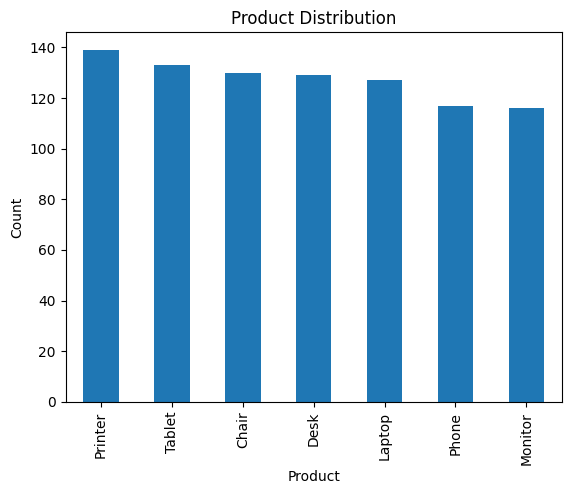

In [21]:
top_products = df["Product"].value_counts()

top_products.plot(kind="bar")

plt.title("Product Distribution")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()

In [22]:
df["PaymentMethod"].value_counts()


PaymentMethod
Cash           183
Gift Card      181
Credit Card    180
Online         178
Debit Card     169
Name: count, dtype: int64

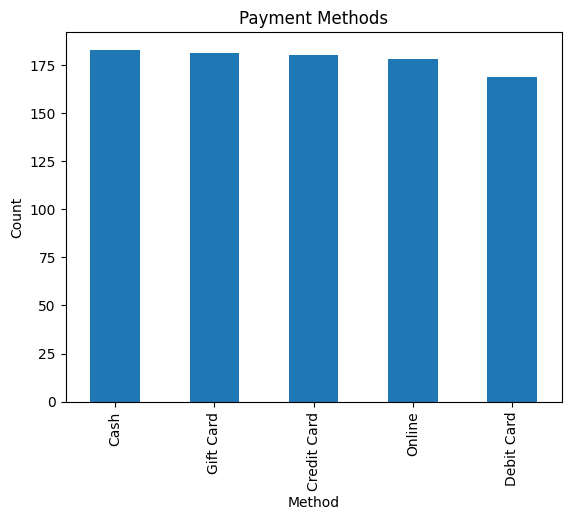

In [23]:
df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Payment Methods")
plt.xlabel("Method")
plt.ylabel("Count")
plt.show()

In [24]:
df["OrderStatus"].value_counts()

OrderStatus
Cancelled    192
Delivered    179
Pending      178
Shipped      171
Returned     171
Name: count, dtype: int64

In [25]:
df["ReferralSource"].value_counts()

ReferralSource
Instagram    198
Email        195
Google       175
Referral     162
Facebook     161
Name: count, dtype: int64

In [26]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

print(monthly_sales)

Month
1      94265.39
2      82016.33
3     101577.44
4      84255.49
5     102875.90
6     115293.24
7      52390.89
8      58636.10
9      54085.99
10     82563.47
11     53271.56
12     61128.75
Name: TotalPrice, dtype: float64


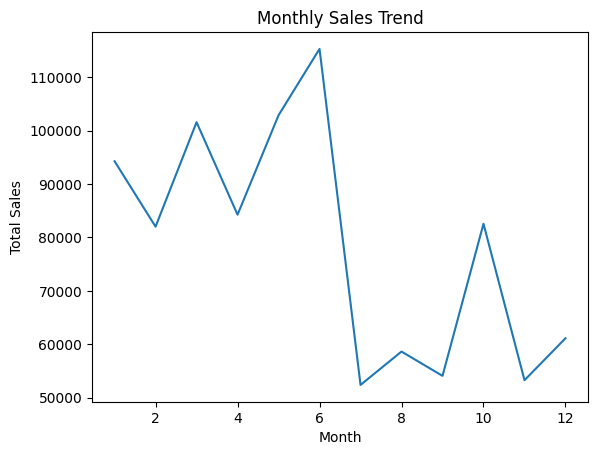

In [27]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [28]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalPrice"] < lower) |
    (df["TotalPrice"] > upper)
]

print("Outliers:", len(outliers))

Outliers: 6


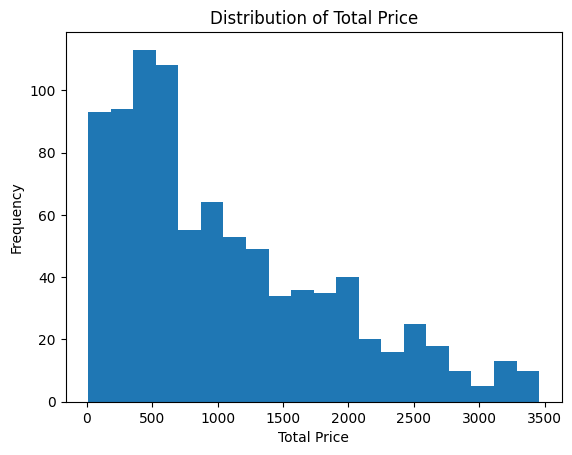

In [29]:
df["TotalPrice"].plot(kind="hist", bins=20)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.show()